<a href="https://colab.research.google.com/github/sahilghogare/Machine-Learning-Experiments/blob/main/ML_Exp_2_NonLinear.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Sahil Suresh Ghogare

Roll no.: 23102A0061

Branch/Div: TE CMPN A

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, accuracy_score, confusion_matrix, classification_report

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving MedicalInsurance.csv to MedicalInsurance.csv


In [ ]:
df = pd.read_csv("MedicalInsurance.csv")
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
df.select_dtypes(include=['object']).columns


Index(['sex', 'smoker', 'region'], dtype='object')

In [ ]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


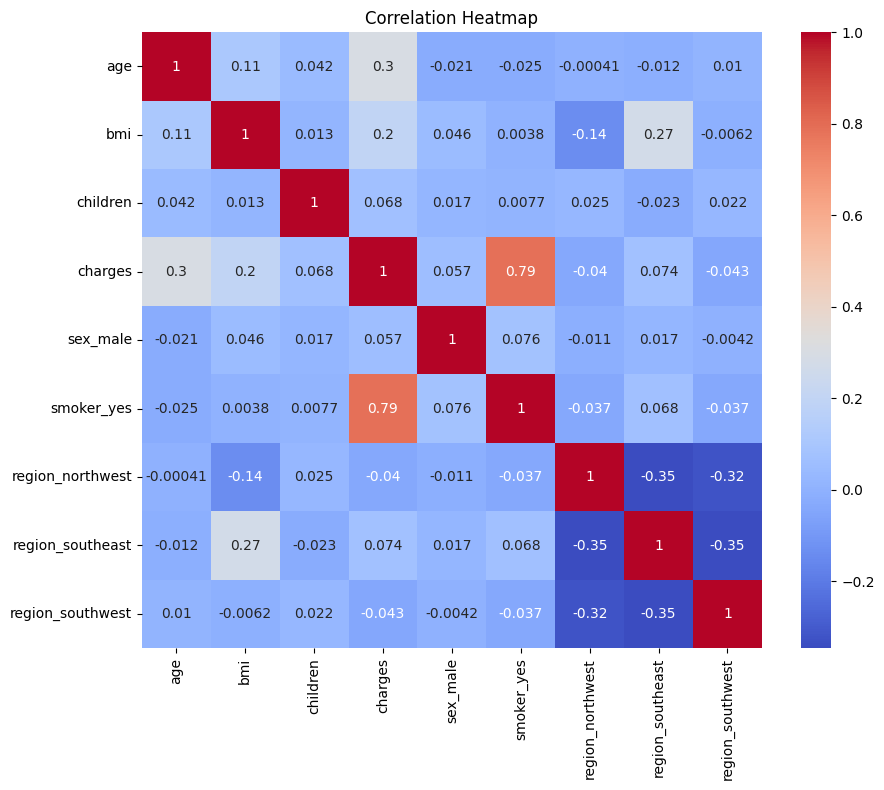

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


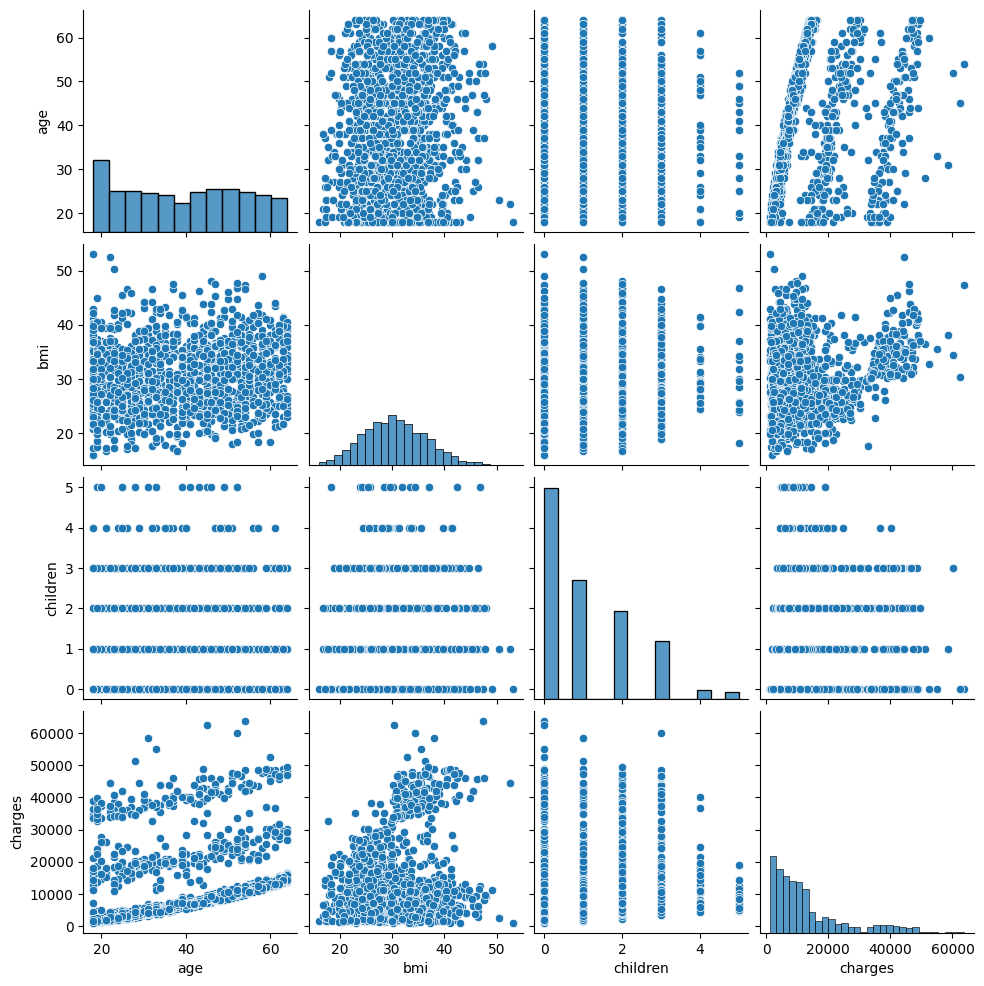

In [ ]:
sns.pairplot(df)
plt.show()


In [ ]:
X = df['age'].values.reshape(-1,1)
y = df['charges'].values


In [ ]:
# Linear
lr = LinearRegression()
lr.fit(X, y)
y_pred_lr = lr.predict(X)

# Polynomial
poly = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),
    ('lr', LinearRegression())
])
poly.fit(X, y)
y_pred_poly = poly.predict(X)

# Logarithmic
X_log = np.log(X)
lr_log = LinearRegression()
lr_log.fit(X_log, y)
y_pred_log = lr_log.predict(X_log)

# Exponential
y_log = np.log(y)
lr_exp = LinearRegression()
lr_exp.fit(X, y_log)
y_pred_exp = np.exp(lr_exp.predict(X))


In [ ]:
print("Linear MSE:", mean_squared_error(y, y_pred_lr))
print("Polynomial MSE:", mean_squared_error(y, y_pred_poly))
print("Logarithmic MSE:", mean_squared_error(y, y_pred_log))
print("Exponential MSE:", mean_squared_error(y, y_pred_exp))


Linear MSE: 133440978.61376347
Polynomial MSE: 133266937.31587408
Logarithmic MSE: 134221316.97774795
Exponential MSE: 145150749.95813066


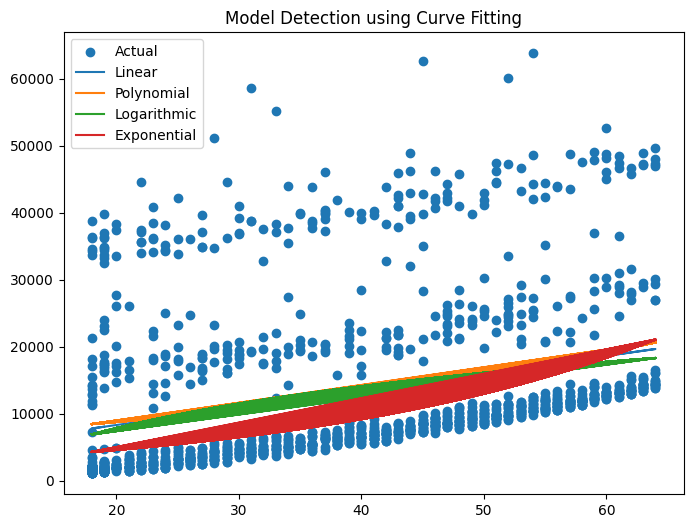

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(X, y, label='Actual')
plt.plot(X, y_pred_lr, label='Linear')
plt.plot(X, y_pred_poly, label='Polynomial')
plt.plot(X, y_pred_log, label='Logarithmic')
plt.plot(X, y_pred_exp, label='Exponential')
plt.legend()
plt.title("Model Detection using Curve Fitting")
plt.show()


In [ ]:
median_charge = df['charges'].median()
df['target'] = (df['charges'] > median_charge).astype(int)

df[['charges','target']].head()


,charges,target
0,16884.92400,1
1,1725.55230,0
2,4449.46200,0
3,21984.47061,1
4,3866.85520,0


In [ ]:
X = df[['age','bmi','children']]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)


LogisticRegression()

In [ ]:
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)


Intercept: [0.06591996]
Coefficients: [[ 1.17045462  0.11411915 -0.03510986]]


In [ ]:
y_pred_prob = model.predict_proba(X_test_scaled)[:,1]
y_pred = model.predict(X_test_scaled)

print("MSE:", mean_squared_error(y_test, y_pred_prob))



MSE: 0.17234698733796913


In [ ]:
pipe = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression())
])

pipe.fit(X_train, y_train)


Pipeline(steps=[('poly', PolynomialFeatures()), ('scaler', StandardScaler()),
                ('model', LogisticRegression())])

In [ ]:
y_pred_poly = pipe.predict(X_test)
y_pred_poly_prob = pipe.predict_proba(X_test)[:,1]

print("Polynomial MSE:", mean_squared_error(y_test, y_pred_poly_prob))
print("Polynomial Accuracy:", accuracy_score(y_test, y_pred_poly))


Polynomial MSE: 0.15667072992202694
Polynomial Accuracy: 0.7723880597014925
